# 4-PLD ASL U-Net Parameter Estimation
**Objective**: Estimate CBF and ATT from 4 ASL PLDs using a 3D U-Net.
**Literature Motivation**: Luciw et al. (2022) successfully used a U-Net on 6-PLD real ASL data.
**Our Adaptation**: Adapted to 4 synthetic ASL PLDs and simultaneous dual-parameter prediction.
**CBF Target**: Channel 0 [ml/100g/min].
**ATT Target**: Channel 1 [s].

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
PyTorch version: 2.5.1+cu121
CUDA available: True
GPU name: NVIDIA GeForce GTX 1650


In [2]:
# Configuration
CONFIG = {
    'PLDs': [1.525, 2.025, 2.525, 3.025],
    'T1t': 1.2, 'T1a': 1.66, 'tau': 1.8, 'alpha': 0.85, 'lambda': 0.9, 'SCALE': 100000.0,
    'n_train': 500, 'n_val': 100, 'n_test': 100,
    'batch_size': 4,
    'epochs': 30,
    'lr': 0.001,
    'seed': 42,
    'num_workers': 0,
    'D': 16, 'H': 32, 'W': 32, # Spatial dimensions
    'patience': 10
}

In [3]:
# Reproducibility
import random
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: NVIDIA GeForce GTX 1650
Memory: 4.29 GB


In [5]:
# Canonical ASL Forward Model (Batched Spatial)
def compute_signals_spatial(cbf, att):
    # cbf, att: [B, D, H, W]
    plds = torch.tensor(CONFIG['PLDs'], dtype=torch.float32, device=cbf.device).view(1, -1, 1, 1, 1)
    cbf_expanded = cbf.unsqueeze(1)
    att_expanded = att.unsqueeze(1)
    
    scale_factor = (2 * CONFIG['alpha'] * CONFIG['T1a'] * cbf_expanded) / (6000 * CONFIG['lambda'])
    dM = torch.zeros_like(plds).expand(cbf.shape[0], len(CONFIG['PLDs']), cbf.shape[1], cbf.shape[2], cbf.shape[3])
    
    cond1 = plds < att_expanded
    cond2 = (plds >= att_expanded) & (plds < (att_expanded + CONFIG['tau']))
    cond3 = plds >= (att_expanded + CONFIG['tau'])
    
    # cond2
    term2 = torch.exp(-att_expanded / CONFIG['T1a']) - torch.exp(-plds / CONFIG['T1a'])
    dM = torch.where(cond2, scale_factor * term2, dM)
    
    # cond3
    term3 = torch.exp(-att_expanded / CONFIG['T1a']) - torch.exp(-(att_expanded + CONFIG['tau']) / CONFIG['T1a'])
    dM = torch.where(cond3, scale_factor * term3, dM)
    
    return dM * CONFIG['SCALE']

In [6]:
# Canonical Dual-Rician Noise Model
def add_noise_spatial(sig, noise_sd, rng=None):
    if rng is None: rng = np.random.default_rng()
    if isinstance(noise_sd, float):
        noise_sd = np.full(sig.shape[0], noise_sd)
    noise_sd = noise_sd[:, None, None, None, None]
    e1 = rng.normal(0.0, noise_sd, size=sig.shape)
    e2 = rng.normal(0.0, noise_sd, size=sig.shape)
    return np.sqrt((sig + e1)**2 + e2**2).astype(np.float32)

# Quick check
test_sig = np.ones((1, 4, 16, 32, 32)) * 50
print("Clean mean:", test_sig.mean())
print("Noisy mean (sd=10):", add_noise_spatial(test_sig, 10.0).mean())

Clean mean: 50.0
Noisy mean (sd=10): 51.05002


In [7]:
# Synthetic Dataset Generation
def generate_spatial_volume(rng, D=16, H=32, W=32):
    z, y, x = np.ogrid[:D, :H, :W]
    cz, cy, cx = D // 2, H // 2, W // 2
    rz, ry, rx = max(1, D // 2 - 1), max(1, H // 2 - 2), max(1, W // 2 - 2)
    mask = ((z - cz)**2 / rz**2 + (y - cy)**2 / ry**2 + (x - cx)**2 / rx**2) <= 1.0
    
    cbf_map = np.zeros((D, H, W))
    for _ in range(rng.integers(3, 6)):
        bz, by, bx = rng.integers(0, D), rng.integers(0, H), rng.integers(0, W)
        sigma = rng.uniform(2.0, 5.0)
        blob = np.exp(-((z - bz)**2 + (y - by)**2 + (x - bx)**2) / (2 * sigma**2))
        cbf_map += blob * rng.uniform(20.0, 50.0)
    cbf_map += 20.0
    cbf_map = np.clip(cbf_map, 20.0, 90.0)
    cbf_map[~mask] = 0.0
    
    att_map = np.zeros((D, H, W))
    for _ in range(rng.integers(3, 6)):
        bz, by, bx = rng.integers(0, D), rng.integers(0, H), rng.integers(0, W)
        sigma = rng.uniform(2.0, 5.0)
        blob = np.exp(-((z - bz)**2 + (y - by)**2 + (x - bx)**2) / (2 * sigma**2))
        att_map += blob * rng.uniform(0.5, 2.0)
    att_map += 0.5
    att_map = np.clip(att_map, 0.5, 3.0)
    att_map[~mask] = 0.0
    
    cbf_t = torch.tensor(cbf_map, dtype=torch.float32).unsqueeze(0)
    att_t = torch.tensor(att_map, dtype=torch.float32).unsqueeze(0)
    clean_sig = compute_signals_spatial(cbf_t, att_t)[0].numpy()
    
    return clean_sig, cbf_map, att_map, mask

class SpatialASLDataset(Dataset):
    def __init__(self, n_volumes, seed, is_train=True):
        self.rng = np.random.default_rng(seed)
        dataset_start = time.perf_counter()
        self.signals, self.cbfs, self.atts, self.masks = [], [], [], []
        
        for _ in range(n_volumes):
            sig, cbf, att, mask = generate_spatial_volume(self.rng, CONFIG['D'], CONFIG['H'], CONFIG['W'])
            self.signals.append(sig)
            self.cbfs.append(cbf)
            self.atts.append(att)
            self.masks.append(mask)
            
        self.signals = np.stack(self.signals)
        self.cbfs = np.stack(self.cbfs)[:, np.newaxis]
        self.atts = np.stack(self.atts)[:, np.newaxis]
        self.masks = np.stack(self.masks)[:, np.newaxis]
        
        self.targets = np.concatenate([self.cbfs, self.atts], axis=1).astype(np.float32)
        
        # Apply varying noise during training
        if is_train:
            noise_sd = self.rng.uniform(0.0, 334.2039/5.0, size=n_volumes)
            self.signals = add_noise_spatial(self.signals, noise_sd, self.rng)
        
        # Normalization
        if is_train:
            self.x_mean = self.signals.mean(axis=(0, 2, 3, 4), keepdims=True)
            self.x_std = self.signals.std(axis=(0, 2, 3, 4), keepdims=True) + 1e-8
            self.y_mean = self.targets.mean(axis=(0, 2, 3, 4), keepdims=True)
            self.y_std = self.targets.std(axis=(0, 2, 3, 4), keepdims=True) + 1e-8
            
        print(f"Dataset generated in {time.perf_counter() - dataset_start:.2f}s")
        print(f"Volumes: {n_volumes}, Shape: {self.signals.shape}")
        
    def normalize(self, x_mean, x_std, y_mean, y_std):
        self.x_mean, self.x_std = x_mean, x_std
        self.y_mean, self.y_std = y_mean, y_std
        
    def __len__(self): return len(self.signals)
    def __getitem__(self, idx):
        x = (self.signals[idx] - self.x_mean[0]) / self.x_std[0]
        y = (self.targets[idx] - self.y_mean[0]) / self.y_std[0]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32), torch.tensor(self.masks[idx])

train_ds = SpatialASLDataset(CONFIG['n_train'], CONFIG['seed'], is_train=True)
val_ds = SpatialASLDataset(CONFIG['n_val'], CONFIG['seed']+1, is_train=False)
test_ds = SpatialASLDataset(CONFIG['n_test'], CONFIG['seed']+2, is_train=False)

val_ds.normalize(train_ds.x_mean, train_ds.x_std, train_ds.y_mean, train_ds.y_std)
test_ds.normalize(train_ds.x_mean, train_ds.x_std, train_ds.y_mean, train_ds.y_std)

Dataset generated in 6.91s
Volumes: 500, Shape: (500, 4, 16, 32, 32)


Dataset generated in 0.62s
Volumes: 100, Shape: (100, 4, 16, 32, 32)


Dataset generated in 0.63s
Volumes: 100, Shape: (100, 4, 16, 32, 32)


Input shape: torch.Size([4, 16, 32, 32])
Target shape: torch.Size([2, 16, 32, 32])


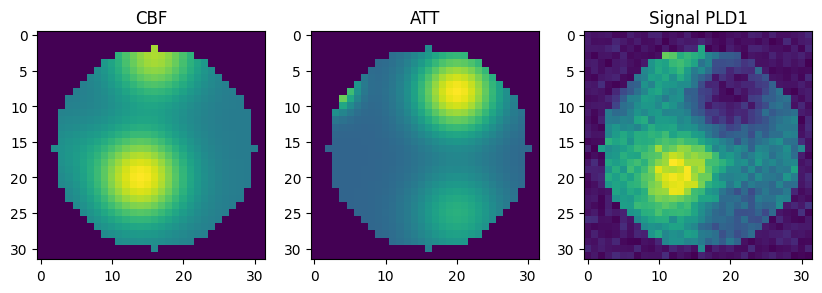

In [8]:
# Dataset Inspection
print("Input shape:", train_ds[0][0].shape)
print("Target shape:", train_ds[0][1].shape)
plt.figure(figsize=(10, 3))
plt.subplot(1,3,1); plt.imshow(train_ds.targets[0, 0, 8, :, :]); plt.title("CBF")
plt.subplot(1,3,2); plt.imshow(train_ds.targets[0, 1, 8, :, :]); plt.title("ATT")
plt.subplot(1,3,3); plt.imshow(train_ds.signals[0, 0, 8, :, :]); plt.title("Signal PLD1")
plt.show()

In [9]:
# Split info
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 500, Val: 100, Test: 100


In [10]:
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'])
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)
print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 125


In [11]:
class LuciwUNet3D(nn.Module):
    def __init__(self, in_channels=4, base_channels=16):
        super().__init__()
        
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv3d(in_c, out_c, 3, padding=1), nn.BatchNorm3d(out_c), nn.ReLU(inplace=True),
                nn.Conv3d(out_c, out_c, 3, padding=1), nn.BatchNorm3d(out_c), nn.ReLU(inplace=True)
            )
            
        self.enc1 = conv_block(in_channels, base_channels)
        self.pool1 = nn.MaxPool3d(kernel_size=(2, 2, 1), stride=(2, 2, 1))
        
        self.enc2 = conv_block(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 1), stride=(2, 2, 1))
        
        self.bottleneck = conv_block(base_channels * 2, base_channels * 4)
        
        self.up2 = nn.ConvTranspose3d(base_channels * 4, base_channels * 2, kernel_size=(2, 2, 1), stride=(2, 2, 1))
        self.dec2 = conv_block(base_channels * 4, base_channels * 2)
        
        self.up1 = nn.ConvTranspose3d(base_channels * 2, base_channels, kernel_size=(2, 2, 1), stride=(2, 2, 1))
        self.dec1 = conv_block(base_channels * 2, base_channels)
        
        self.final = nn.Conv3d(base_channels, 2, kernel_size=1)
        
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        
        d2 = self.up2(b)
        d2 = torch.cat([e2, d2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([e1, d1], dim=1)
        d1 = self.dec1(d1)
        
        return self.final(d1)

model = LuciwUNet3D().to(device)

In [12]:
# Parameter count
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {params:,} (Comparable to Arch02-05 ~11k, though convolutions are distributed spatially)")

Total trainable parameters: 330,962 (Comparable to Arch02-05 ~11k, though convolutions are distributed spatially)


In [13]:
# Sanity Check
bx, by, bm = next(iter(train_loader))
out = model(bx.to(device))
print("Input:", bx.shape)
print("Output:", out.shape)
assert out.shape == by.shape, "Shape mismatch!"
print("Sanity Check Passed.")

Input: torch.Size([4, 4, 16, 32, 32])
Output: torch.Size([4, 2, 16, 32, 32])
Sanity Check Passed.


In [14]:
# Loss
def masked_l1_loss(pred, target, mask):
    # Loss only in brain voxels
    mask_b = mask.expand_as(pred)
    return nn.L1Loss(reduction='sum')(pred[mask_b], target[mask_b]) / (mask_b.sum() + 1e-8)

In [15]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [16]:
# Timing Test
model.train()
t0 = time.perf_counter()
bx, by, bm = next(iter(train_loader))
bx, by, bm = bx.to(device), by.to(device), bm.to(device)
if device.type == 'cuda': torch.cuda.synchronize()
t_data = time.perf_counter() - t0

t0 = time.perf_counter()
pred = model(bx)
if device.type == 'cuda': torch.cuda.synchronize()
t_fwd = time.perf_counter() - t0

t0 = time.perf_counter()
loss = masked_l1_loss(pred, by, bm)
loss.backward()
if device.type == 'cuda': torch.cuda.synchronize()
t_bwd = time.perf_counter() - t0

t0 = time.perf_counter()
optimizer.step()
if device.type == 'cuda': torch.cuda.synchronize()
t_opt = time.perf_counter() - t0

print(f"Data: {t_data:.4f}s | Fwd: {t_fwd:.4f}s | Bwd: {t_bwd:.4f}s | Opt: {t_opt:.4f}s")

Data: 0.0046s | Fwd: 0.0125s | Bwd: 0.3001s | Opt: 0.0531s


In [17]:
# Validation function
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for bx, by, bm in loader:
            bx, by, bm = bx.to(device), by.to(device), bm.to(device)
            pred = model(bx)
            loss = masked_l1_loss(pred, by, bm)
            total_loss += loss.item() * bx.size(0)
    return total_loss / len(loader.dataset)

In [18]:
# Full Training Loop
history = []
best_val = float('inf')
best_ep = 0
patience_counter = 0

start_train = time.perf_counter()

for ep in range(CONFIG['epochs']):
    model.train()
    ep_start = time.perf_counter()
    train_loss = 0.0
    for bx, by, bm in train_loader:
        bx, by, bm = bx.to(device), by.to(device), bm.to(device)
        optimizer.zero_grad()
        pred = model(bx)
        loss = masked_l1_loss(pred, by, bm)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * bx.size(0)
        
    if device.type == 'cuda': torch.cuda.synchronize()
    ep_time = time.perf_counter() - ep_start
    train_loss /= len(train_loader.dataset)
    
    val_loss = evaluate(model, val_loader)
    
    cum_time = time.perf_counter() - start_train
    print(f"Epoch {ep+1:03d}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Epoch Time: {ep_time:.2f} s | Total: {cum_time:.2f} s")
    
    history.append({'epoch': ep+1, 'train_loss': train_loss, 'val_loss': val_loss, 'epoch_time': ep_time})
    
    if val_loss < best_val:
        best_val = val_loss
        best_ep = ep + 1
        patience_counter = 0
        os.makedirs('results/unet_4pld', exist_ok=True)
        torch.save(model.state_dict(), 'results/unet_4pld/best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print("Early stopping!")
            break

total_train_time = time.perf_counter() - start_train

Epoch 001/30 | Train Loss: 0.2605 | Val Loss: 0.1110 | Epoch Time: 6.98 s | Total: 7.29 s


Epoch 002/30 | Train Loss: 0.1547 | Val Loss: 0.0907 | Epoch Time: 6.95 s | Total: 14.56 s


Epoch 003/30 | Train Loss: 0.1366 | Val Loss: 0.1140 | Epoch Time: 6.99 s | Total: 21.87 s


Epoch 004/30 | Train Loss: 0.1258 | Val Loss: 0.1135 | Epoch Time: 6.97 s | Total: 29.14 s


Epoch 005/30 | Train Loss: 0.1228 | Val Loss: 0.0814 | Epoch Time: 6.98 s | Total: 36.42 s


...

Epoch 026/30 | Train Loss: 0.0548 | Val Loss: 0.0381 | Epoch Time: 7.13 s | Total: 192.08 s


Epoch 027/30 | Train Loss: 0.0571 | Val Loss: 0.0512 | Epoch Time: 7.10 s | Total: 199.49 s


Epoch 028/30 | Train Loss: 0.0555 | Val Loss: 0.0370 | Epoch Time: 7.16 s | Total: 206.95 s


Epoch 029/30 | Train Loss: 0.0532 | Val Loss: 0.0389 | Epoch Time: 7.24 s | Total: 214.52 s


Epoch 030/30 | Train Loss: 0.0551 | Val Loss: 0.0455 | Epoch Time: 7.16 s | Total: 222.00 s


In [19]:
print(f"Best epoch: {best_ep}")
print(f"Best validation loss: {best_val:.4f}")

Best epoch: 28
Best validation loss: 0.0370


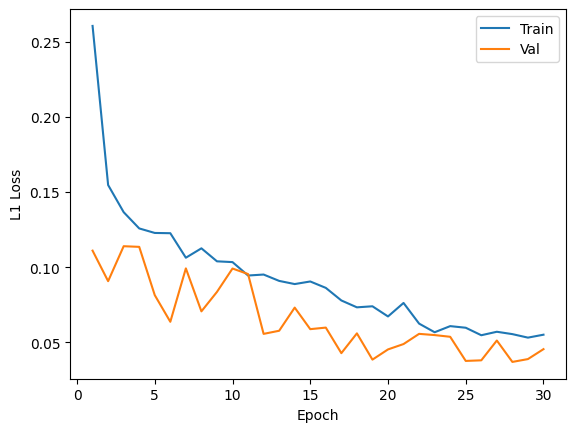

In [20]:
df_hist = pd.DataFrame(history)
plt.plot(df_hist['epoch'], df_hist['train_loss'], label='Train')
plt.plot(df_hist['epoch'], df_hist['val_loss'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('L1 Loss'); plt.legend(); plt.show()

In [21]:
print(f"Total training time: {total_train_time:.2f} s")
print(f"Average epoch time: {df_hist['epoch_time'].mean():.2f} s")
if torch.cuda.is_available():
    print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

Total training time: 222.00 s
Average epoch time: 7.09 s
Peak GPU memory: 0.16 GB


In [22]:
# Load best checkpoint
model.load_state_dict(torch.load('results/unet_4pld/best_model.pt', map_location=device))
model.eval();

C:\Users\ANU THOMSON\AppData\Local\Temp\ipykernel_6776\3672165968.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('results/unet_4pld/bes

In [23]:
# Test Evaluation
def eval_test(model, ds, snr=None):
    if snr is None:
        noise_sd = 0.0
    else:
        noise_sd = 334.2039 / snr
    
    clean_signals = ds.signals
    noisy = add_noise_spatial(clean_signals, noise_sd, np.random.default_rng(77))
    norm_noisy = (noisy - train_ds.x_mean) / train_ds.x_std
    
    loader = DataLoader(TensorDataset(torch.tensor(norm_noisy, dtype=torch.float32), 
                                      torch.tensor(ds.targets, dtype=torch.float32), 
                                      torch.tensor(ds.masks)), batch_size=4)
    preds = []
    with torch.no_grad():
        for bx, by, bm in loader:
            p = model(bx.to(device)).cpu().numpy()
            preds.append(p)
    preds = np.concatenate(preds, axis=0)
    
    # Rescale back to physical units
    preds_phys = preds * train_ds.y_std[0] + train_ds.y_mean[0]
    
    mask = ds.masks[:, 0].astype(bool)
    err = preds_phys - ds.targets
    cbf_err = err[:, 0][mask]
    att_err = err[:, 1][mask]
    
    return {
        'SNR': snr if snr else float('inf'),
        'CBF RMSE': np.sqrt(np.mean(cbf_err**2)),
        'ATT RMSE': np.sqrt(np.mean(att_err**2))
    }

snr_results = [eval_test(model, test_ds, snr) for snr in [None, 50, 20, 15, 10, 5]]
df_snr = pd.DataFrame(snr_results)
print(df_snr)

    SNR  CBF RMSE  ATT RMSE
0   inf  0.821564  0.023438
1  50.0  0.825871  0.022644
2  20.0  0.839331  0.022720
3  15.0  0.850259  0.023367
4  10.0  0.879116  0.025793
5   5.0  1.012335  0.037483


In [24]:
# SNR Robustness Table
print("SNR Robustness (CBF / ATT RMSE):")
print(df_snr.to_string(index=False))

SNR Robustness (CBF / ATT RMSE):
 SNR  CBF RMSE  ATT RMSE
 inf  0.821564  0.023438
50.0  0.825871  0.022644
20.0  0.839331  0.022720
15.0  0.850259  0.023367
10.0  0.879116  0.025793
 5.0  1.012335  0.037483


In [25]:
# Save Results
df_snr.to_csv('results/unet_4pld/snr_robustness.csv', index=False)
df_hist.to_csv('results/unet_4pld/history.csv', index=False)
print("Saved to results/unet_4pld/")

Saved to results/unet_4pld/


In [26]:
print("=== EXPERIMENT SUMMARY ===")
print("Model: 3D U-Net")
print(f"Parameters: {params:,}")
print(f"Dataset Size: {CONFIG['n_train']}")
print(f"Best Epoch: {best_ep}")
print(f"Best Val Loss: {best_val:.4f}")
print(f"Total Train Time: {total_train_time:.1f} s")
print(f"Mean Epoch Time: {df_hist['epoch_time'].mean():.2f} s")
print(f"Clean CBF RMSE: {df_snr.iloc[0]['CBF RMSE']:.3f}")
print(f"Clean ATT RMSE: {df_snr.iloc[0]['ATT RMSE']:.3f}")
print(f"SNR 5 CBF RMSE: {df_snr.iloc[-1]['CBF RMSE']:.3f}")
print(f"SNR 5 ATT RMSE: {df_snr.iloc[-1]['ATT RMSE']:.3f}")

=== EXPERIMENT SUMMARY ===
Model: 3D U-Net
Parameters: 330,962
Dataset Size: 500
Best Epoch: 28
Best Val Loss: 0.0370
Total Train Time: 222.0 s
Mean Epoch Time: 7.09 s
Clean CBF RMSE: 0.822
Clean ATT RMSE: 0.023
SNR 5 CBF RMSE: 1.012
SNR 5 ATT RMSE: 0.037
